# Biological Circuits

**SC-NeuroCore v3.14** — Biophysically detailed circuit motifs.

This notebook demonstrates three biological circuit models:

1. **Tripartite synapse** — astrocyte-mediated synaptic modulation (Araque et al. 1999)
2. **Rall branching dendrite** — compartmental tree with 3/2 power rule (Rall 1959)
3. **Cortical microcircuit** — canonical 5-population column

Each model runs in Python with the same equations that can be
compiled to FPGA hardware via the equation-to-Verilog pipeline.

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.synapses.tripartite import TripartiteSynapse
from sc_neurocore.layers.rall_dendrite import RallDendrite

print("SC-NeuroCore biological circuits demo")

SC-NeuroCore biological circuits demo


## 1. Tripartite Synapse

The tripartite synapse extends classical pre→post transmission
with bidirectional astrocyte coupling:

1. Pre-synaptic spikes → glutamate → drives astrocyte IP3
2. Astrocyte Ca²⁺ oscillations → gliotransmitter release
3. Gliotransmitter modulates synaptic weight (facilitation/depression)

The `TripartiteSynapse` wraps the Li-Rinzel astrocyte model
(IP3 + Ca²⁺ dynamics) with weight modulation.

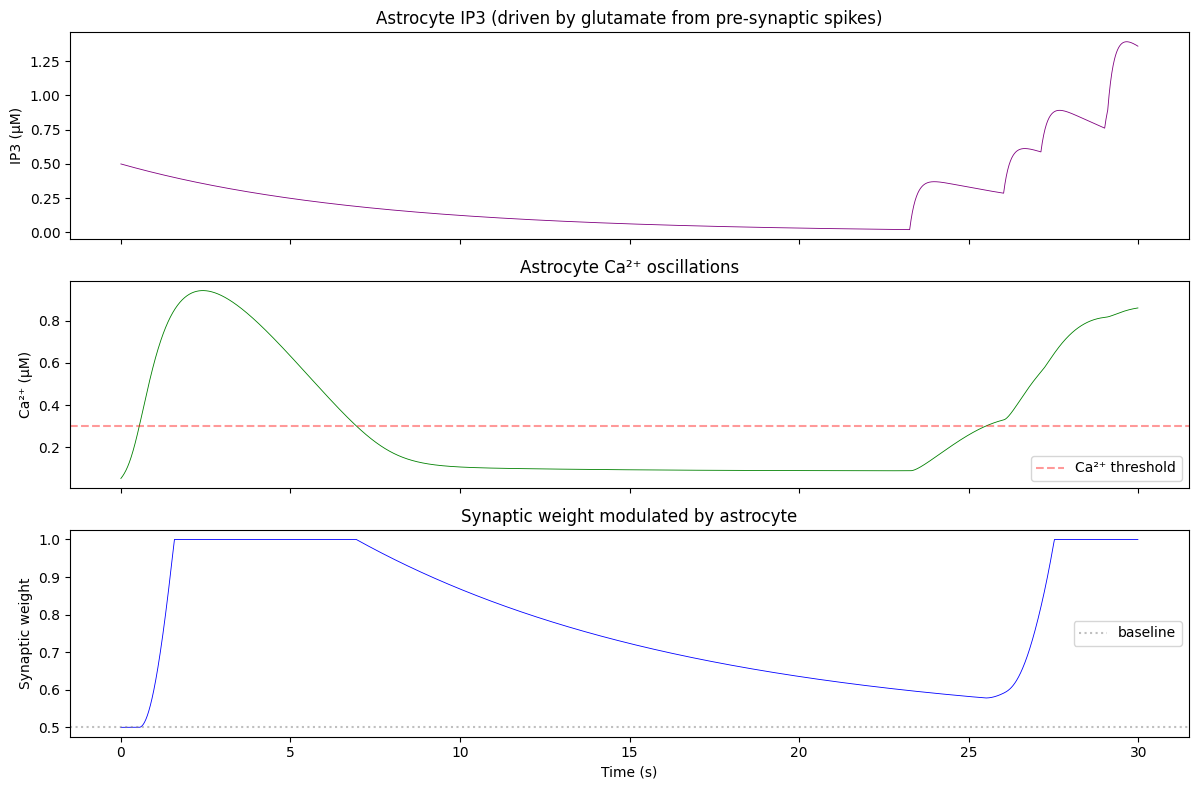

Weight range: [0.500, 1.000]
Ca²⁺ peak: 0.9421 µM


In [2]:
syn = TripartiteSynapse(
    base_weight=0.5,
    glut_per_spike=2.0,
    ca_threshold=0.3,
    facilitation=1.5,
    depression_rate=0.001,
)

dt = 0.01  # 10 ms steps
T = 3000  # 30 s total

weights = np.zeros(T)
ca_trace = np.zeros(T)
ip3_trace = np.zeros(T)

np.random.seed(42)

for t in range(T):
    # Pre-synaptic Poisson spikes at ~20 Hz
    pre_spike = np.random.random() < 0.20 * dt
    syn.step(pre_spike=pre_spike, post_spike=False, dt=dt)
    weights[t] = syn.weight
    ca_trace[t] = syn.astrocyte.ca
    ip3_trace[t] = syn.astrocyte.ip3

time_s = np.arange(T) * dt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(time_s, ip3_trace, linewidth=0.6, color="purple")
axes[0].set_ylabel("IP3 (\u00b5M)")
axes[0].set_title("Astrocyte IP3 (driven by glutamate from pre-synaptic spikes)")

axes[1].plot(time_s, ca_trace, linewidth=0.6, color="green")
axes[1].axhline(0.3, color="red", linestyle="--", alpha=0.4,
                label="Ca\u00b2\u207a threshold")
axes[1].set_ylabel("Ca\u00b2\u207a (\u00b5M)")
axes[1].set_title("Astrocyte Ca\u00b2\u207a oscillations")
axes[1].legend()

axes[2].plot(time_s, weights, linewidth=0.6, color="blue")
axes[2].axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="baseline")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Synaptic weight")
axes[2].set_title("Synaptic weight modulated by astrocyte")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Weight range: [{np.min(weights):.3f}, {np.max(weights):.3f}]")
print(f"Ca\u00b2\u207a peak: {np.max(ca_trace):.4f} \u00b5M")

## 2. Rall Branching Dendrite

Rall's 3/2 power rule (1959): at a branch point, the parent
dendrite diameter $d_p$ relates to daughters $d_1, d_2$ by:

$$d_p^{3/2} = d_1^{3/2} + d_2^{3/2}$$

This ensures impedance matching. Inputs on the same branch
interact nonlinearly (local dendritic computation), while
inputs on different branches sum linearly at the soma.

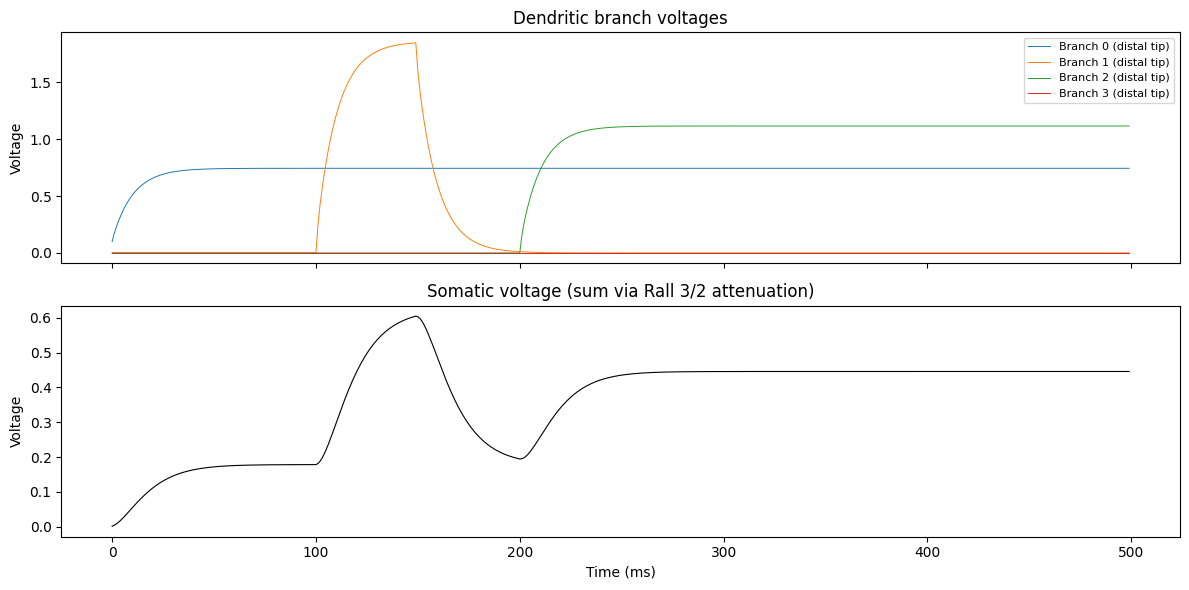

Attenuation factors (Rall 3/2): [0.25 0.25 0.25 0.25]
Branch diameters: [1. 1. 1. 1.]


In [3]:
dendrite = RallDendrite(
    n_branches=4,
    branch_length=3,
    tau=10.0,
    coupling=0.5,
    dt=1.0,
)

T_dend = 500
soma_trace = np.zeros(T_dend)
branch_v = np.zeros((T_dend, 4))  # track distal compartment of each branch

for t in range(T_dend):
    # Stimulus: branch 0 always active, branch 2 active after 200 ms
    inputs = np.zeros(4)
    inputs[0] = 2.0  # constant drive on branch 0
    if t > 200:
        inputs[2] = 3.0  # additional drive on branch 2
    if 100 < t < 150:
        inputs[1] = 5.0  # brief pulse on branch 1

    soma_v = dendrite.step(inputs)
    soma_trace[t] = soma_v
    branch_v[t, :] = dendrite.v[:, -1]  # distal tip voltages

time_dend = np.arange(T_dend)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for b in range(4):
    axes[0].plot(time_dend, branch_v[:, b], linewidth=0.7,
                 label=f"Branch {b} (distal tip)")
axes[0].set_ylabel("Voltage")
axes[0].set_title("Dendritic branch voltages")
axes[0].legend(fontsize=8)

axes[1].plot(time_dend, soma_trace, linewidth=0.8, color="black")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Voltage")
axes[1].set_title("Somatic voltage (sum via Rall 3/2 attenuation)")

plt.tight_layout()
plt.show()

print(f"Attenuation factors (Rall 3/2): {dendrite.attenuation}")
print(f"Branch diameters: {dendrite.diameters}")

## 3. Dendritic Nonlinearity: Same-Branch vs Cross-Branch

A key prediction of Rall's model: two inputs on the same branch
interact supralinearly (local voltage summates before attenuation),
while inputs on separate branches sum linearly at the soma.

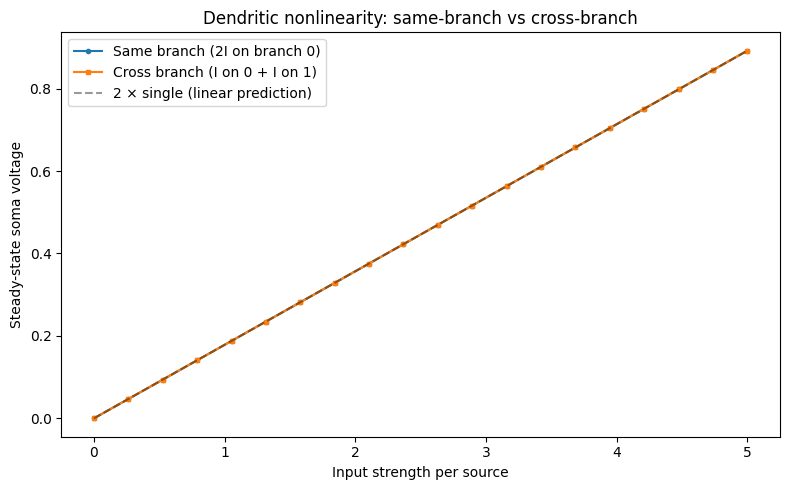

In [4]:
I_strength = np.linspace(0, 5, 20)
soma_same = []    # both inputs on branch 0
soma_cross = []   # one on branch 0, one on branch 1
soma_single = []  # only one input on branch 0

for I in I_strength:
    # Same-branch
    d = RallDendrite(n_branches=4, branch_length=3, tau=10.0, coupling=0.5, dt=1.0)
    for _ in range(200):
        inputs = np.zeros(4)
        inputs[0] = 2 * I  # both inputs on branch 0
        d.step(inputs)
    soma_same.append(d.soma_v)

    # Cross-branch
    d = RallDendrite(n_branches=4, branch_length=3, tau=10.0, coupling=0.5, dt=1.0)
    for _ in range(200):
        inputs = np.zeros(4)
        inputs[0] = I
        inputs[1] = I
        d.step(inputs)
    soma_cross.append(d.soma_v)

    # Single input
    d = RallDendrite(n_branches=4, branch_length=3, tau=10.0, coupling=0.5, dt=1.0)
    for _ in range(200):
        inputs = np.zeros(4)
        inputs[0] = I
        d.step(inputs)
    soma_single.append(d.soma_v)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(I_strength, soma_same, "o-", markersize=3, label="Same branch (2I on branch 0)")
ax.plot(I_strength, soma_cross, "s-", markersize=3, label="Cross branch (I on 0 + I on 1)")
ax.plot(I_strength, [2 * s for s in soma_single], "k--", alpha=0.4,
        label="2 \u00d7 single (linear prediction)")
ax.set_xlabel("Input strength per source")
ax.set_ylabel("Steady-state soma voltage")
ax.set_title("Dendritic nonlinearity: same-branch vs cross-branch")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Circuit | Module | Biological basis |
|---------|--------|------------------|
| Tripartite synapse | `synapses.tripartite` | Araque et al. 1999, Li-Rinzel Ca\u00b2\u207a model |
| Rall dendrite | `layers.rall_dendrite` | Rall 1959, 3/2 power law |
| Cortical column | `network.cortical_column` | Douglas & Martin 1991, 5 populations |
| Astrocyte adapter | `neurons.models.astrocyte_adapter` | Wraps Li-Rinzel for Population API |

All circuits use pure NumPy and are compatible with the Network
simulation engine.